In [1]:
!sudo apt-get install -y fonts-nanum
# 폰트 설치 후 Colab 메뉴에서 런타임/세션 다시 시작을 선택합니다.

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (7,585 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126380 files and dire

In [ ]:
!pip install -U openai

In [ ]:
from google.colab import userdata
import os
import openai

# Colab에 저장한 Secret에서 API 키 가져와 환경 변수에 등록
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

client = openai.OpenAI()

In [ ]:
import pandas as pd

# 예제 iris 데이터셋 불러오기
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
print(df.head(5))

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [ ]:
df.to_markdown()

'|     |   sepal_length |   sepal_width |   petal_length |   petal_width | species    |\n|----:|---------------:|--------------:|---------------:|--------------:|:-----------|\n|   0 |            5.1 |           3.5 |            1.4 |           0.2 | setosa     |\n|   1 |            4.9 |           3   |            1.4 |           0.2 | setosa     |\n|   2 |            4.7 |           3.2 |            1.3 |           0.2 | setosa     |\n|   3 |            4.6 |           3.1 |            1.5 |           0.2 | setosa     |\n|   4 |            5   |           3.6 |            1.4 |           0.2 | setosa     |\n|   5 |            5.4 |           3.9 |            1.7 |           0.4 | setosa     |\n|   6 |            4.6 |           3.4 |            1.4 |           0.3 | setosa     |\n|   7 |            5   |           3.4 |            1.5 |           0.2 | setosa     |\n|   8 |            4.4 |           2.9 |            1.4 |           0.2 | setosa     |\n|   9 |            4.9 |       

In [ ]:
prompt_summary = f"""
다음은 Iris 꽃 데이터셋입니다. sepal_length, sepal_width, petal_length, petal_width 컬럼으로
꽃의 크기 특성이 주어지고 species 컬럼으로 품종(setosa, versicolor, virginica)이 구분됩니다.

데이터:
{df.to_markdown()}

이 데이터의 주요 특성을 요약하고, 간단한 인사이트 3가지를 불릿 목록으로 알려주세요.
"""

response = client.chat.completions.create(
    messages=[
        {"role": "user", "content": prompt_summary}
    ],
    model="gpt-4o"
)

summary_text = response.choices[0].message.content
print(summary_text)

Iris 데이터셋은 3개의 품종(setosa, versicolor, virginica)의 꽃에 대한 샘플을 포함하고 있으며 각 샘플에는 꽃의 크기 특성을 나타내는 4개의 수치적 컬럼(sepal_length, sepal_width, petal_length, petal_width)이 있습니다. 이 데이터셋은 150개의 샘플로 구성되어 있고, 각 품종별로 50개의 샘플이 포함되어 있습니다.

### 주요 특성 요약:

1. **품종 분류**:
   - 각 품종은 sepal과 petal의 길이 및 너비 측면에서 서로 다른 크기 특성을 가지며, 이를 통해 품종을 구분할 수 있다.
   - 'setosa', 'versicolor', 'virginica'의 3가지 품종으로 나뉜다.

2. **크기 특성**:
   - 'setosa'는 대체로 petal의 길이와 너비가 다른 두 품종 대비 작고, sepal은 비교적 넓다.
   - 'versicolor'는 중간 크기의 꽃을 가지며, 스펙트럼의 중간에 위치해 있다.
   - 'virginica'는 상대적으로 긴 petal과 더 큰 sepal 사이즈를 가진다.

3. **데이터 분포**:
   - 모든 변수가 연속형 변수이며, 다양한 길이와 너비에 걸쳐 비교적 고르게 분포되어 있다.

### 인사이트:

- **품종 구분의 용이성**: Bias-variance 측면에서 'setosa' 품종은 주어진 데이터의 특성만으로도 다른 두 품종에 비해 훨씬 명확히 구분 가능하다. Petal의 크기가 세 가지 품종 중 가장 작다는 특징이 명확하다.

- **꽃 크기 경향성**: 데이터셋의 전반적인 경향성을 보면, 일반적으로 petal 크기가 커질수록(길이와 너비 모두) virginica에서 setosa로 갈수록 감소하는 경향이 있다.

- **변수 간 상관관계**: petal_length와 petal_width 간의 강한 상관관계가 존재할 가능성이 있으며, 이는 차별화된 특성 추론에 유리하게 작용할 수 있다. 이를 통해 보다 쉽게 품종 분류

In [ ]:
prompt_code = f"""

데이터:
{df.to_markdown()}

데이터를 활용하여 품종(species)별 꽃받침(sepal)의 길이와 너비 관계를 나타내는 산점도를 그리는
Python 코드를 작성해줘. matplotlib 라이브러리를 사용하고, 품종(species)에 따라 다른 색으로 표시하고
범례를 포함하도록 해줘.
"""

response = client.chat.completions.create(
    messages=[
        {"role": "user", "content": prompt_code}
    ],
    model="gpt-4o-mini"
)

code_text = response.choices[0].message.content
print(code_text)

아래는 주어진 데이터를 이용하여 matplotlib을 사용하여 품종별 꽃받침(sepal)의 길이와 너비 관계를 나타내는 산점도를 그리는 Python 코드입니다.

```python
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 생성
data = {
    "sepal_length": [
        5.1, 4.9, 4.7, 4.6, 5.0, 5.4, 4.6, 5.0, 4.4, 4.9,
        5.4, 4.8, 4.8, 4.3, 5.8, 5.7, 5.4, 5.1, 5.7, 5.1,
        5.4, 5.1, 4.6, 5.1, 4.8, 5.0, 5.0, 5.2, 5.2, 4.7,
        4.8, 5.4, 5.2, 5.5, 4.9, 5.0, 5.5, 4.9, 4.4, 5.1,
        5.0, 4.5, 4.4, 5.0, 5.1, 4.8, 5.1, 4.6, 5.3, 5.0,
        7.0, 6.4, 6.9, 5.5, 6.5, 5.7, 6.3, 4.9, 6.6, 5.2,
        5.0, 5.9, 6.0, 6.1, 5.6, 6.7, 5.6, 5.8, 6.2, 5.6,
        5.9, 6.1, 6.3, 6.1, 6.4, 6.6, 6.8, 6.7, 6.0, 5.7,
        5.5, 5.5, 6.1, 5.8, 5.0, 5.6, 5.7, 5.7, 6.2, 5.1,
        5.7, 6.3, 5.8, 7.1, 6.3, 6.5, 7.6, 4.9, 7.3, 6.7,
        7.2, 6.5, 6.4, 6.8, 5.7, 5.8, 6.4, 6.5, 7.7, 7.7,
        6.0, 6.9, 5.6, 7.7, 6.3, 6.7, 7.2, 6.2, 6.1, 6.4,
        7.2, 7.4, 7.9, 6.4, 6.3, 6.1, 7.7, 6.3, 6.4, 6.9,
        6.7, 6.9, 5.8, 6.8, 6.7, 6.7, 6.3, 6.5, 6.2,

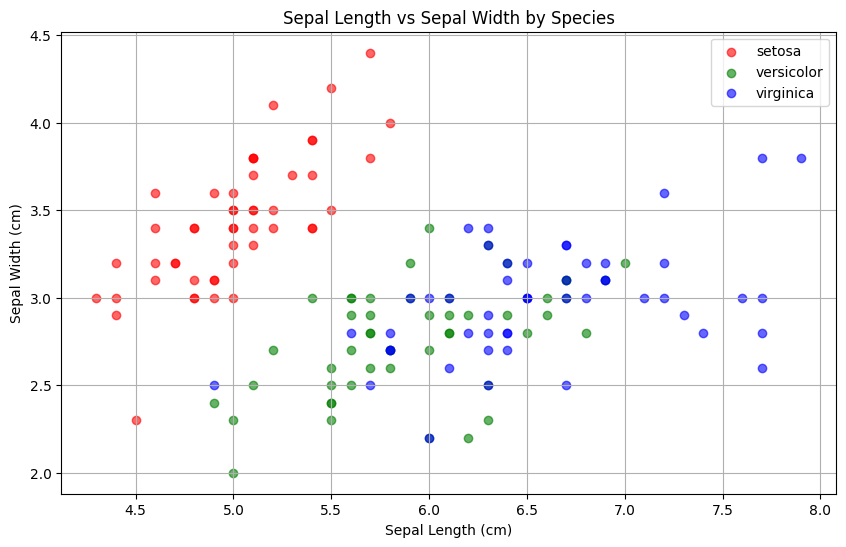

In [ ]:
import matplotlib.pyplot as plt

# 품종별로 색상 매핑
colors = {'setosa': 'red', 'versicolor': 'green', 'virginica': 'blue'}

# 산점도 그리기
plt.figure(figsize=(10, 6))
for species, color in colors.items():
    subset = df[df['species'] == species]
    plt.scatter(subset['sepal_length'], subset['sepal_width'],
                color=color, label=species, alpha=0.6)

# 제목과 레이블 추가
plt.title('Sepal Length vs Sepal Width by Species')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend()
plt.grid(True)

# 그래프를 화면에 표시
plt.show()